In [65]:
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt

from spectral.io.envi import read_envi_header

# from scipy.interpolate import CubicSpline
# from scipy.interpolate import PchipInterpolator # to avoid negative values
from scipy.interpolate import interp1d # or then why not just the simple 1d interpolation?
from scipy.interpolate import RectBivariateSpline # for covariance matrix

from scipy.io import loadmat, savemat

In [2]:
extra_data = '/home/carroll/isofit/extra-downloads/data/'

In [31]:
# load data
noise = np.loadtxt(extra_data + 'avirisng_noise.txt')
wvl = noise[...,0]
a = noise[...,1]
b = noise[...,2]
c = noise[...,3]
rmse = noise[...,4]

wvl_neon = [float(x) for x in read_envi_header('/store/carroll/col/2018/raw/rmbl/2018061914/NIS01_20180619_153052_rdn.hdr')['wavelength']]

In [33]:
# simplest possible solution, 1d interpolation
interp_a = interp1d(wvl, a, kind='linear', fill_value='extrapolate')
interp_b = interp1d(wvl, b, kind='linear', fill_value='extrapolate')
interp_c = interp1d(wvl, c, kind='linear', fill_value='extrapolate')
interp_rmse = interp1d(wvl, rmse, kind='linear', fill_value='extrapolate')

a_new = interp_a(wvl_neon)
b_new = interp_b(wvl_neon)
c_new = interp_c(wvl_neon)
rmse_new = interp_rmse(wvl_neon)

In [24]:
# alternatives: CubicSpline, PchipInterpolator (unclear necessary?)

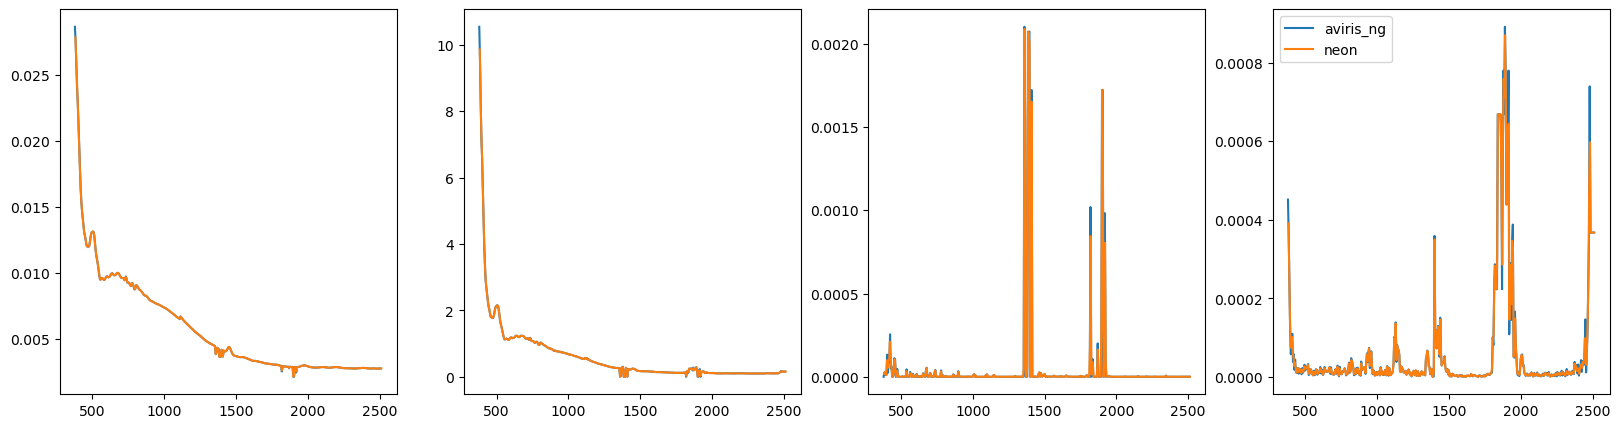

In [34]:
# visualize change
fig, axs = plt.subplots(ncols=4, figsize=(20,5))

# original 
axs[0].plot(wvl, a, label='aviris_ng')
axs[1].plot(wvl, b, label='aviris_ng')
axs[2].plot(wvl, c, label='aviris_ng')
axs[3].plot(wvl, rmse, label='aviris_ng')

# neon model
axs[0].plot(wvl_neon, a_new, label='neon')
axs[1].plot(wvl_neon, b_new, label='neon')
axs[2].plot(wvl_neon, c_new, label='neon')
axs[3].plot(wvl_neon, rmse_new, label='neon')

plt.legend()
plt.show()

In [35]:
# export in same format
noise_neon = np.column_stack([wvl_neon, a_new, b_new, c_new, rmse_new])
header = '#      wvl       a       b       c      rmse'
np.savetxt('/store/carroll/col/avirisng_noise_neon.txt', noise_neon, fmt='%.7f', header=header, comments='')

In [39]:
# now also look at systematic error?

systematic_error = np.loadtxt(extra_data+'avirisng_systematic_error.txt')
wvl = systematic_error[...,0]
error = systematic_error[...,1]
wvl_neon = [float(x) for x in read_envi_header('/store/carroll/col/2018/raw/rmbl/2018061914/NIS01_20180619_153052_rdn.hdr')['wavelength']]

interp_ = interp1d(wvl, error, kind='linear', fill_value='extrapolate')
error_new = interp_(wvl_neon)

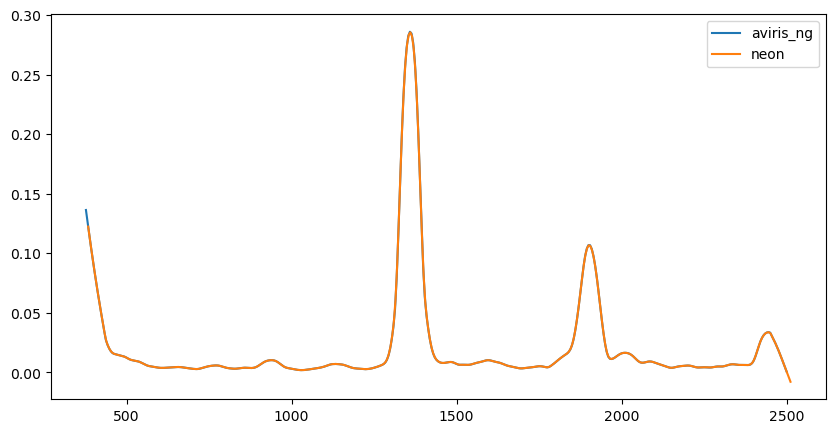

In [41]:
fig = plt.subplots(figsize=(10,5))
plt.plot(wvl, error, label='aviris_ng')
plt.plot(wvl_neon, error_new, label='neon')
plt.legend()
plt.show()

In [43]:
# export in same format
systematic_error_neon = np.column_stack([wvl_neon, error_new])
header = '# Wavelength, 1-sigma systematic calibration / radiative transfer errors'
np.savetxt('/store/carroll/col/avirisng_systematic_error_neon.txt', systematic_error_neon, fmt='%.7f', header=header, comments='')

In [57]:
# what's up with the model discrepancy mat
wvl_neon = [float(x) for x in read_envi_header('/store/carroll/col/2018/raw/rmbl/2018061914/NIS01_20180619_153052_rdn.hdr')['wavelength']]

model_discrepancy = loadmat(extra_data + 'avirisng_model_discrepancy.mat')
print(model_discrepancy.keys())
model_discrepancy['wl'].shape, model_discrepancy['cov'].shape

dict_keys(['__header__', '__version__', '__globals__', 'wl', 'cov'])


((1, 425), (425, 425))

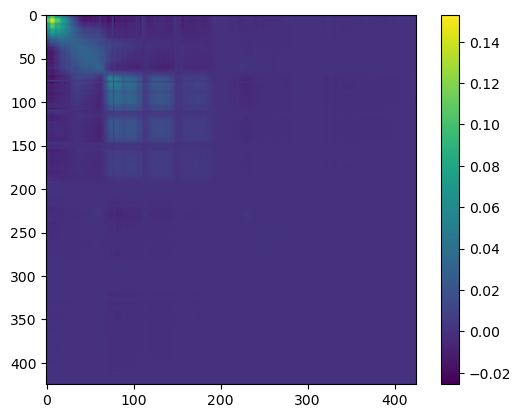

In [56]:
plt.imshow(model_discrepancy['cov'])
plt.colorbar()

In [61]:
# just try the interpolation?
interp_cov = RectBivariateSpline(model_discrepancy['wl'], model_discrepancy['wl'], model_discrepancy['cov'])
cov_new = interp_cov(wvl_neon, wvl_neon)

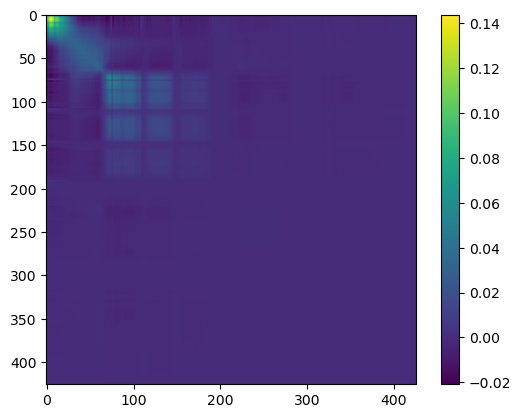

In [62]:
plt.imshow(cov_new)
plt.colorbar()

In [63]:
# enforce symmetry, because interpolation can break perfect symmetry due to floating point rounding?
cov_new_symmetrical = 0.5 * (cov_new + cov_new.T)

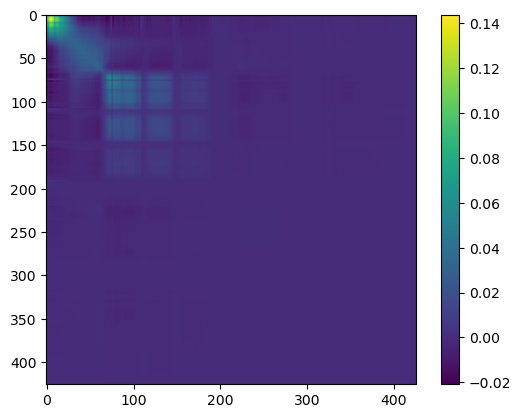

In [64]:
plt.imshow(cov_new_symmetrical)
plt.colorbar()

In [ ]:
# try this without "projecting to nearst PSD matrix"

In [68]:
# export
savemat('/store/carroll/col/avirisng_model_discrepancy_neon.mat', {
    'wl': wvl_neon,
    'cov': cov_new_symmetrical
})